# Disease-Specific Knowledge Mapping (Unsupervised Clustering)

This notebook implements a pipeline for grouping biomedical documents into clusters to identify underlying disease-related topics and patterns.

## Pipeline Overview:
1. **Data Loading**: Load PubMed abstracts related to various diseases.
2. **Preprocessing**: Clean and tokenize text data.
3. **TF-IDF Feature Extraction**: Transform text into numerical features.
4. **UMAP Dimensionality Reduction**: Reduce feature space while preserving structure.
5. **Clustering**: Group documents using KMeans or HDBSCAN.
6. **Evaluation**: Assess clustering quality.
7. **Keyword Extraction & Mapping**: Interpret clusters and map to disease knowledge.
8. **Visualization**: Plot clusters in 2D space.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import umap
import hdbscan
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from wordcloud import WordCloud
from tqdm import tqdm

# Set aesthetic style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)

# Setup results directory
results_dir = 'TF-IDF Results'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

print("Libraries imported and environment setup.")

d:\Spring 25-26\IDS\About Project\ICCA\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported and environment setup.


## Step 1: Data Loading
We load the biomedical dataset containing PubMed abstracts.

Dataset loaded: 14065 documents

Disease distribution in dataset:
Disease
cancer neoplasm                1951
diabetes mellitus              1922
stroke cerebrovascular         1880
Alzheimer disease dementia     1753
hypertension blood pressure    1747
cardiovascular disease         1722
neurological disorders         1586
Parkinson disease              1504
Name: count, dtype: int64


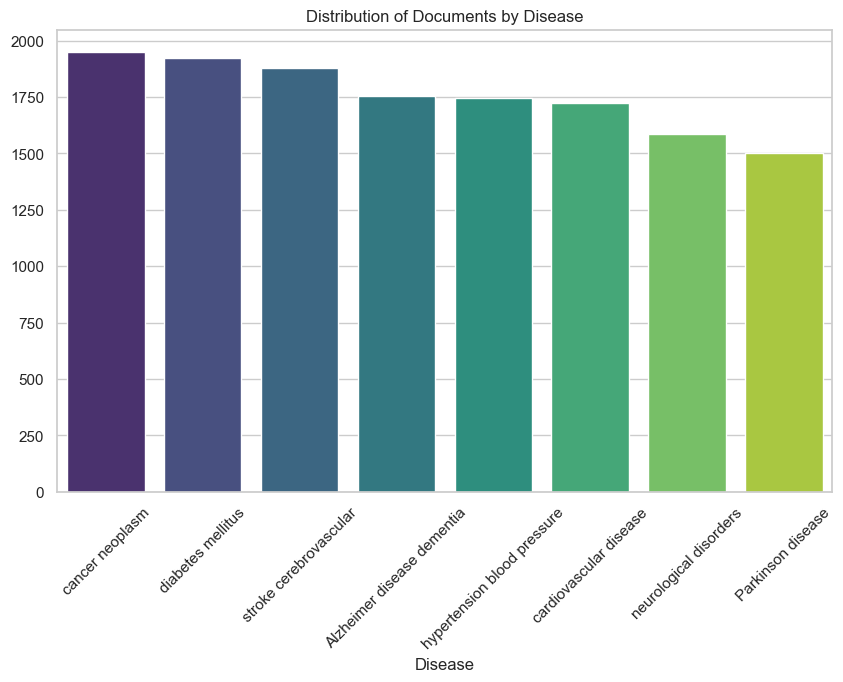

,PMID,Title,Abstract,Disease
0,42125794,Secondary Prevention After Coronary Artery Byp...,Coronary artery bypass grafting is a well-esta...,diabetes mellitus
1,42125665,Identification of biomarkers in diabetic neuro...,This study elucidated several plasma proteins ...,diabetes mellitus
2,42125629,Neutrophil-Percentage-to-Albumin Ratio and Mon...,Elderly patients with diabetes mellitus (DM) a...,diabetes mellitus
3,42125581,Changes in the Mental Health Status of Rural C...,Population aging is causing the rise in physic...,diabetes mellitus
4,42125565,Proportion of Presumptive Knee Osteoarthritis ...,Knee osteoarthritis (OA) is a common joint dis...,diabetes mellitus


In [2]:
# Load data
df = pd.read_csv('pubmed_dataset.csv')
print(f"Dataset loaded: {df.shape[0]} documents")

# Display disease distribution
disease_counts = df['Disease'].value_counts()
print("\nDisease distribution in dataset:")
print(disease_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=disease_counts.index, y=disease_counts.values, hue=disease_counts.index, palette="viridis")
plt.title("Distribution of Documents by Disease")
plt.xticks(rotation=45)
plt.show()

df.head()

## Step 2: Preprocessing
Cleaning the text by removing punctuation, digits, and stopwords, then tokenizing.

In [3]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if pd.isna(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and short words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

print("Preprocessing abstracts (this may take a minute)...")
tqdm.pandas()
df['Cleaned_Abstract'] = df['Abstract'].progress_apply(preprocess_text)

# Remove empty abstracts if any
df = df[df['Cleaned_Abstract'] != ""]

# Save cleaned corpus
cleaned_path = os.path.join(results_dir, 'step2_cleaned_corpus.csv')
df.to_csv(cleaned_path, index=False)
print(f"Preprocessing complete. Cleaned data saved to {cleaned_path}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ROWTECH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ROWTECH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ROWTECH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing abstracts (this may take a minute)...


100%|██████████| 14065/14065 [00:08<00:00, 1664.85it/s]


Preprocessing complete. Cleaned data saved to TF-IDF Results\step2_cleaned_corpus.csv


## Step 3: TF-IDF Feature Extraction
Converting cleaned text into numerical TF-IDF features.

In [ ]:
print("Vectorizing text with TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.9, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Cleaned_Abstract'])
print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")

# Save a sample of TF-IDF features for inspection
tfidf_sample = pd.DataFrame(tfidf_matrix[:100].toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_sample.to_csv(os.path.join(results_dir, 'step3_tfidf_sample.csv'), index=False)
print("TF-IDF sample saved.")

Vectorizing text with TF-IDF...


## Step 4: UMAP Dimensionality Reduction
Reducing the high-dimensional TF-IDF space to 2 dimensions for clustering and visualization.

In [ ]:
print("Reducing dimensionality with UMAP...")
reducer = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
umap_embedding = reducer.fit_transform(tfidf_matrix)

# Add UMAP coordinates to dataframe
df['UMAP_1'] = umap_embedding[:, 0]
df['UMAP_2'] = umap_embedding[:, 1]

# Save UMAP results
umap_results_path = os.path.join(results_dir, 'step4_umap_results.csv')
df.to_csv(umap_results_path, index=False)
print(f"UMAP reduction complete. Results saved to {umap_results_path}")

Reducing dimensionality with UMAP...


d:\Spring 25-26\IDS\About Project\ICCA\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP reduction complete. Results saved to TF-IDF Results\step4_umap_results.csv


## Step 5: Clustering
Using KMeans to group the documents into clusters based on their UMAP coordinates.

--- Step 5: Enhanced Clustering ---
Running Elbow Method...


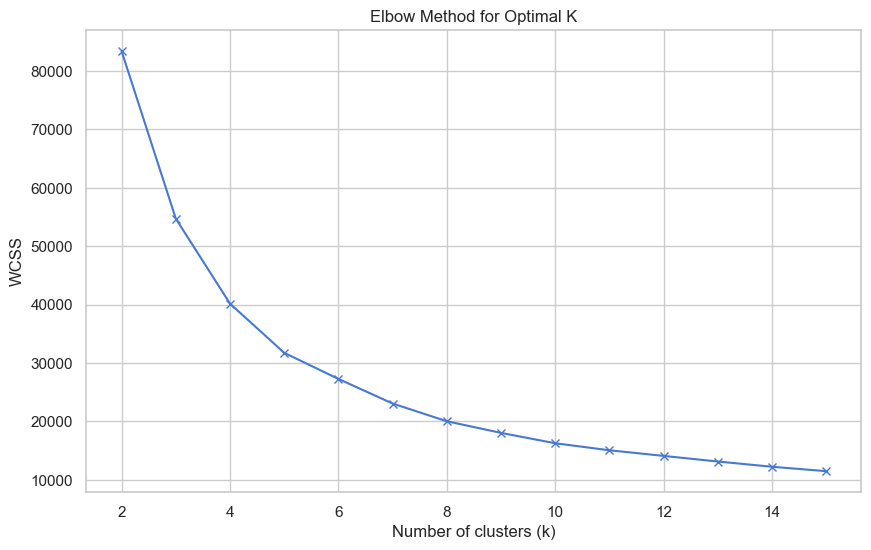

Running KMeans with K=8...
Running HDBSCAN...
Running Hierarchical Clustering...
Clustering complete. Columns added: KMeans_Cluster, HDBSCAN_Cluster, Hierarchical_Cluster


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
import hdbscan
import numpy as np

print("--- Step 5: Enhanced Clustering ---")

# A. Elbow Method to find optimal K
print("Running Elbow Method...")
wcss = []
k_range = range(2, 16)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(umap_embedding)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

# Based on Elbow or Domain Knowledge (setting to 8 for consistency)
optimal_k = 8 

# B. K-Means
print(f"Running KMeans with K={optimal_k}...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(umap_embedding)

# C. HDBSCAN (Density-Based)
print("Running HDBSCAN...")
hdb = hdbscan.HDBSCAN(min_cluster_size=50, gen_min_span_tree=True)
df['HDBSCAN_Cluster'] = hdb.fit_predict(umap_embedding)

# D. Hierarchical Clustering
print("Running Hierarchical Clustering...")
hier = AgglomerativeClustering(n_clusters=optimal_k)
df['Hierarchical_Cluster'] = hier.fit_predict(umap_embedding)

print("Clustering complete. Columns added: KMeans_Cluster, HDBSCAN_Cluster, Hierarchical_Cluster")

## Step 6: Evaluation Metrics
Evaluating the clustering performance using Silhouette Score and Davies–Bouldin Index.

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("--- Step 6: Comparative Evaluation ---")

def evaluate(labels, name):
    # Use a sample for speed if dataset is large
    sample_idx = np.random.choice(len(umap_embedding), min(2000, len(umap_embedding)), replace=False)
    sil = silhouette_score(umap_embedding[sample_idx], labels[sample_idx])
    db = davies_bouldin_score(umap_embedding[sample_idx], labels[sample_idx])
    return sil, db

results = []
for col in ['KMeans_Cluster', 'HDBSCAN_Cluster', 'Hierarchical_Cluster']:
    # Filter out noise (-1) for HDBSCAN metric calculation
    mask = df[col] != -1
    if mask.sum() > 1:
        sil, db = evaluate(df[col].values, col)
        results.append({'Algorithm': col, 'Silhouette': sil, 'DB_Index': db})

eval_df = pd.DataFrame(results)
print(eval_df)

# Save results to CSV
eval_df.to_csv(os.path.join(results_dir, 'clustering_comparative_metrics.csv'), index=False)

--- Step 6: Comparative Evaluation ---
              Algorithm  Silhouette  DB_Index
0        KMeans_Cluster    0.370256  0.793399
1       HDBSCAN_Cluster    0.055280  3.706853
2  Hierarchical_Cluster    0.297492  0.875032


## Step 7: Keyword Extraction per Cluster
Identifying the top keywords that define each cluster.

In [ ]:
def get_top_keywords(texts, n=10):
    vec = CountVectorizer(stop_words='english').fit(texts)
    bag_of_words = vec.transform(texts)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return [w[0] for w in words_freq[:n]]

print("Extracting top keywords per cluster...")
cluster_keywords = {}
for i in range(n_clusters):
    cluster_texts = df[df['Cluster'] == i]['Cleaned_Abstract']
    keywords = get_top_keywords(cluster_texts)
    cluster_keywords[i] = keywords
    print(f"Cluster {i}: {', '.join(keywords)}")

# Save keywords to CSV
keyword_df = pd.DataFrame.from_dict(cluster_keywords, orient='index', columns=[f'Keyword_{i+1}' for i in range(10)])
keyword_df.to_csv(os.path.join(results_dir, 'step7_cluster_keywords.csv'))
print("Cluster keywords saved.")

Extracting top keywords per cluster...


NameError: name 'n_clusters' is not defined

## Step 8: Disease Knowledge Mapping
Analyzing the relationship between clusters and the original disease labels.

In [ ]:
cluster_disease_dist = df.groupby(['Cluster', 'Disease']).size().unstack(fill_value=0)
print("\nCluster vs Disease Distribution:")
print(cluster_disease_dist)

cluster_disease_dist.to_csv(os.path.join(results_dir, 'step8_cluster_disease_mapping.csv'))
print("Knowledge mapping results saved.")


Cluster vs Disease Distribution:
Disease  Alzheimer disease dementia  Parkinson disease  cancer neoplasm  \
Cluster                                                                   
0                               644                470               39   
1                                23                 29               61   
2                                11                 24              624   
3                                63                 41               40   
4                               498                578              101   
5                                83                 95              791   
6                               328                158              175   
7                               103                109              119   

Disease  cardiovascular disease  diabetes mellitus  \
Cluster                                              
0                            57                 49   
1                           481                182   

## Step 9: Visualization
Plotting the results in UMAP space.

Generating final visualizations...


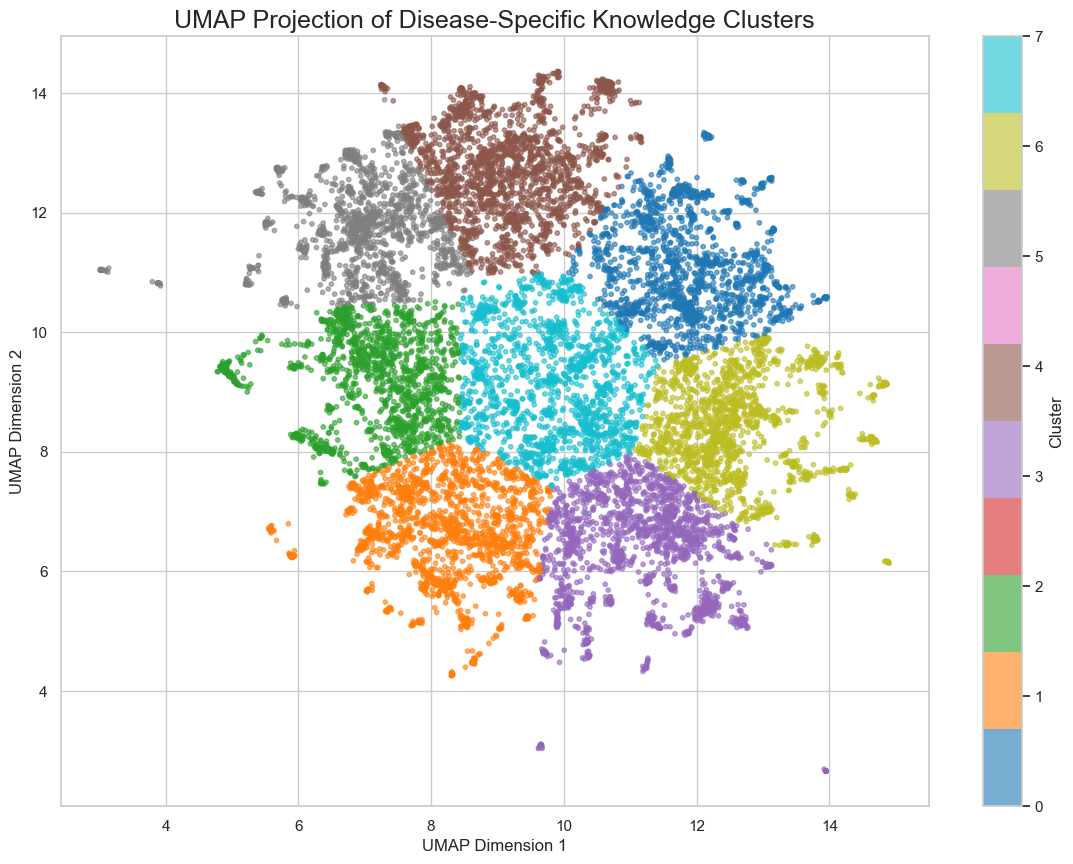

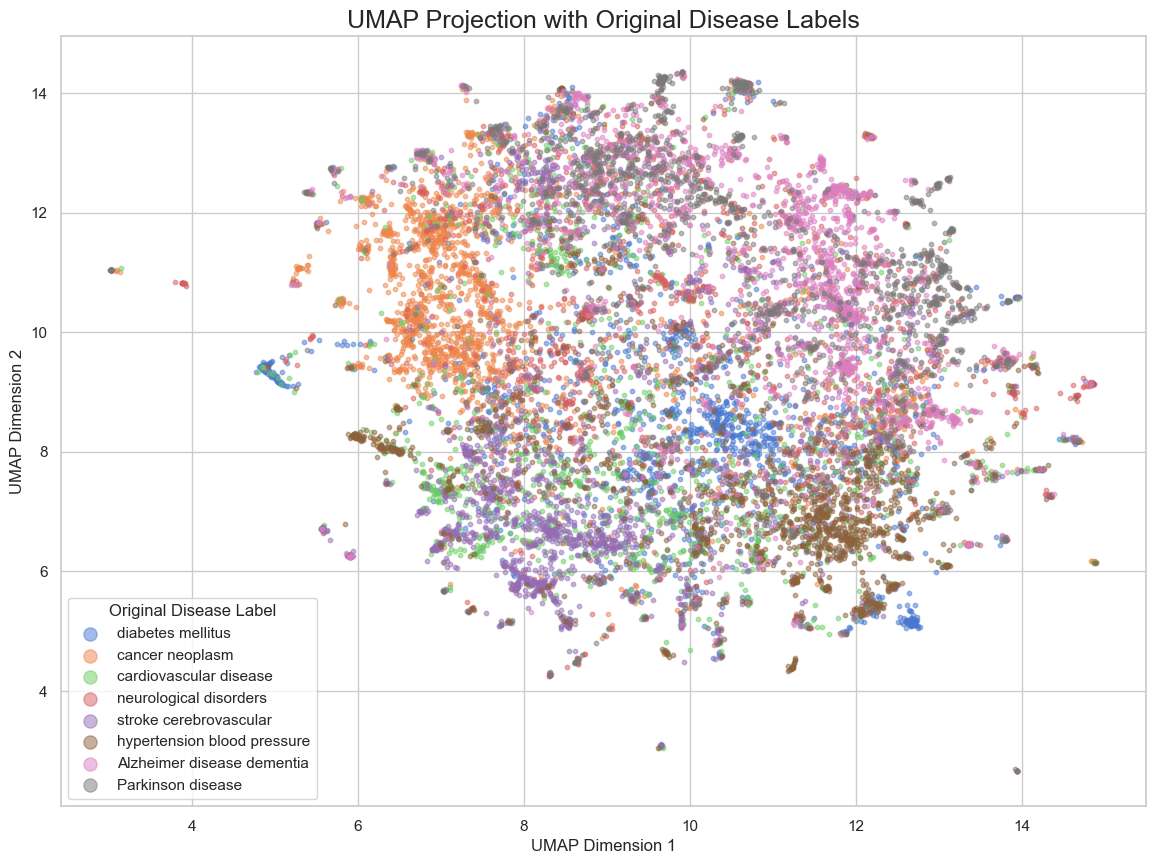

All visualizations saved to TF-IDF Results


In [ ]:
print("Generating final visualizations...")

# Plot clusters
plt.figure(figsize=(14, 10))
scatter = plt.scatter(df['UMAP_1'], df['UMAP_2'], c=df['Cluster'], cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title('UMAP Projection of Disease-Specific Knowledge Clusters', fontsize=18)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.savefig(os.path.join(results_dir, 'umap_clusters_plot.png'))
plt.show()

# Comparison with original labels
plt.figure(figsize=(14, 10))
diseases = df['Disease'].unique()
for disease in diseases:
    mask = df['Disease'] == disease
    plt.scatter(df.loc[mask, 'UMAP_1'], df.loc[mask, 'UMAP_2'], label=disease, alpha=0.5, s=10)
plt.legend(markerscale=3, title="Original Disease Label")
plt.title('UMAP Projection with Original Disease Labels', fontsize=18)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.savefig(os.path.join(results_dir, 'umap_original_labels_plot.png'))
plt.show()

print(f"All visualizations saved to {results_dir}")